# $P(\lambda_{ob} | \lambda_{true}, z_t)$ Comparison

Matteo made the optimization of memoizing the following integral:

$$
\int_{\Delta \lambda_{ob}} d\lambda_{ob} P(\lambda_{ob} | \lambda_{tr}, z_{tr})
$$

And interpolating over $\lambda_{tr}, z_{tr}$. Fortunately, he has data files of his results, so we can compare our $P(\lambda_{ob} | \lambda_{true}, z_{true})$ implementation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [368]:
lambda_bin_data = np.array([20, 27.9, 37.6, 50.3, 69.3, 140.0])
zt_int = np.linspace(0.0, 0.55, 56)
lt_int = np.linspace(1.0, 250, 250)

nlbin, nzbin, nltbin = len(lambda_bin_data), len(zt_int), len(lt_int)

int_PDF = np.zeros((nlbin - 1, nzbin - 1, nltbin - 1))
for n in range(nlbin - 1):
    int_PDF[n,:,:] = np.loadtxt('int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_{}_v27_0.dat'.format(n + 1))
    print('int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_{}_v27_0.dat'.format(n + 1))

data = [], [], [], []
for i, z in enumerate(zt_int[:-1]):
    for j, lt in enumerate(lt_int[:-1]):
        for _bin in range(nlbin - 1):
            data[0].append(_bin)
            data[1].append(z)
            data[2].append(lt)
            data[3].append(int_PDF[_bin, i, j])
        
df = pd.DataFrame({'bin': data[0], 'zt': data[1], 'lt': data[2], 'lc_lt_integrated': data[3]})
df[df['lt'] == 100].dropna()

int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_1_v27_0.dat
int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_2_v27_0.dat
int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_3_v27_0.dat
int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_4_v27_0.dat
int_P_lob_ltr/int_P_lob_ltr_ztr_Deltal_5_v27_0.dat


,bin,zt,lt,lc_lt_integrated
495,0,0.00,100.0,0.000000
496,1,0.00,100.0,0.000000
497,2,0.00,100.0,0.000600
498,3,0.00,100.0,0.000400
499,4,0.00,100.0,0.930000
...,...,...,...,...
67725,0,0.54,100.0,0.000000
67726,1,0.54,100.0,0.000000
67727,2,0.54,100.0,0.000000
67728,3,0.54,100.0,0.003371


# Comparison to Our integrals

We compare to tables of our integrations, computed from the `./test/integrate_lc_lt` executable.

(0.0, 50.0)

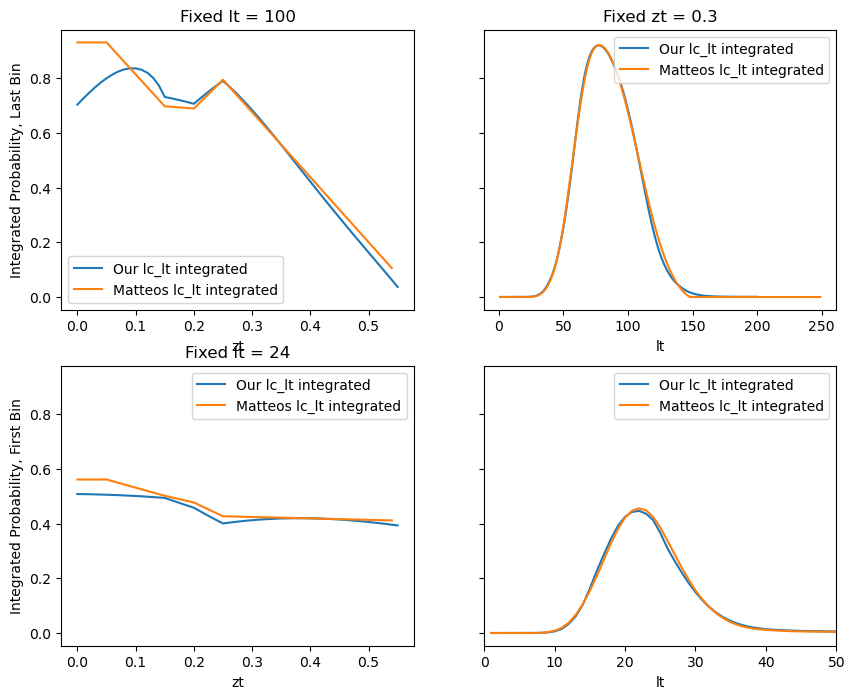

In [7]:
# First, make our plots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]
ax1.set_ylabel('Integrated Probability, Last Bin')
ax3.set_ylabel('Integrated Probability, First Bin')

fixed_lt_slice = df[(df['lt'] == 100) & (df['bin'] == 4)].dropna()
our_fixed_lt_slice = pd.read_csv('int_P_lob_ltr/our_data/last_bin_lambda_100.csv')

fixed_zt_slice = df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 4)].dropna()
our_fixed_zt_slice = pd.read_csv('int_P_lob_ltr/our_data/last_bin_zt_0_3.csv')

our_fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax1)
fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax1)

our_fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax2)
fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax2)

ax1.set_title('Fixed lt = 100')
ax2.set_title('Fixed zt = 0.3')

fixed_lt_slice = df[(df['lt'] == 24) & (df['bin'] == 0)].dropna()
our_fixed_lt_slice = pd.read_csv('int_P_lob_ltr/our_data/first_bin_lambda_24.csv')

fixed_zt_slice = df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 0)].dropna()
our_fixed_zt_slice = pd.read_csv('int_P_lob_ltr/our_data/first_bin_zt_0_3.csv')

our_fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax3)
fixed_lt_slice.plot('zt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax3)

our_fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax4)
fixed_zt_slice.plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax4)

ax3.set_title('Fixed lt = 24')
ax4.set_xlim((0, 50))

In [78]:
# fixed_lt_slice

In [79]:
# # Get our data on a grid
our_data_grid = pd.read_csv('int_P_lob_ltr/our_data/first_bin_grid.csv')
# our_data_grid = our_data_grid[our_data_grid['lt'] < 50].dropna()

# # Get matteos data on the same grid
# matteos_data_grid = df[(df['lt'] <= 50) &
#                        (df['zt'] >= 0.1) & (df['zt'] <= 0.3) &
#                        (df['bin'] == 0)].dropna()

# matteos_data_grid

# def plot_contour(data2d, ax=plt.gca(), xlabel=None, ylabel=None, vmin=None, vmax=None):
#     X = data2d.columns.values
#     Y = data2d.index.values
#     Z = data2d.values
#     x, y = np.meshgrid(X, Y)
    
#     print(X, Z)
#     ret = ax.contourf(x, y, Z, vmin=vmin, vmax=vmax)
#     if xlabel:
#         ax.set_xlabel(xlabel, fontsize=20)
#     if ylabel:
#         ax.set_ylabel(ylabel, fontsize=20)
#     return ret

# our_data_grid = our_data_grid.pivot(columns=['lt', 'zt', 'lc_lt_integrated'])#.to_numpy()
# matteos_data_grid = matteos_data_grid.pivot(columns=['lt', 'zt', 'lc_lt_integrated'])#.to_numpy()

# plt.figure('Our grid')
# map_ = plot_contour(our_data_grid, ax=plt.gca())
# plt.colorbar(map_)

# plt.figure('Matteos grid')
# map_ = plot_contour(matteos_data_grid, ax=plt.gca())
# plt.colorbar(map_)

# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)
# fig.suptitle('Differences for bin 1 (lambda=[20,27.9])', fontsize=20)
# ax1.set_title('Absolute Difference (Matteo - Us)', fontsize=15)
# map_ = plot_contour(our_data_grid - matteos_data_grid, ax=ax1,
#                     xlabel='Redshift', ylabel='Richness')
# ax2.set_title('Relative Difference (Matteo - Us) / Matteo', fontsize=15)
# plot_contour((our_data_grid - matteos_data_grid) / matteos_data_grid, ax=ax2,
#              xlabel='Redshift', ylabel='Richness')
# fig.colorbar(map_)

In [29]:
# our_data_grid.columns.values

In [30]:
# help(our_data_grid.pivot)

In [81]:
# our_data_grid

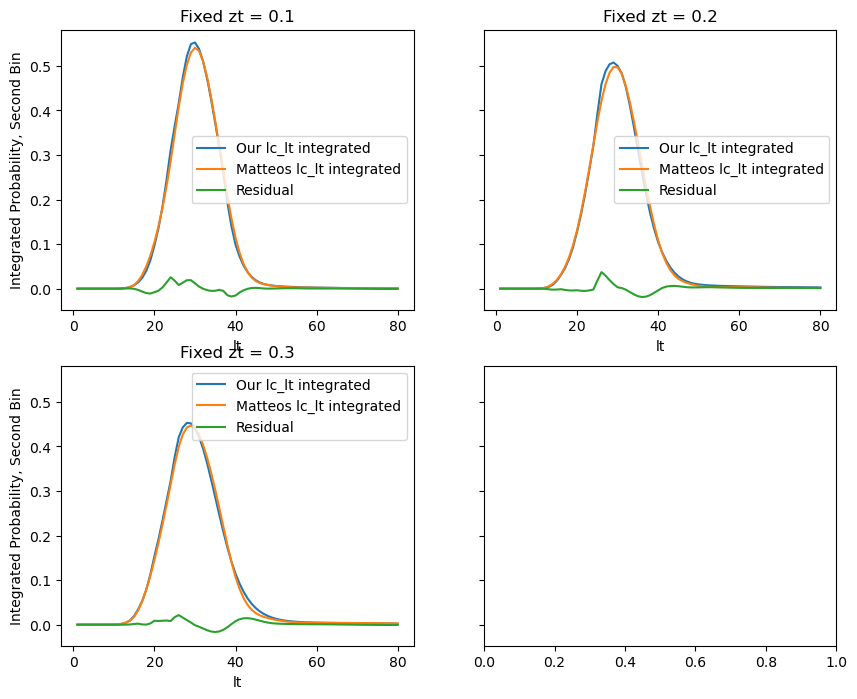

In [32]:
# First, make our plots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]
ax1.set_ylabel('Integrated Probability, Second Bin')
ax3.set_ylabel('Integrated Probability, Second Bin')

matteos_zt = [df[((df['zt'] - 0.1).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna(),
              df[((df['zt'] - 0.2).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna(),
              df[((df['zt'] - 0.3).abs() < 0.007) & (df['bin'] == 1) &
                 (df['lt'] <= 80)].dropna()]
our_zt = [pd.read_csv('int_P_lob_ltr/our_data/second_bin_zt_0_{}.csv'.format(i))
          for i in (1, 2, 3)]

ax1.set_title('Fixed zt = 0.1')
our_zt[0].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax1)
matteos_zt[0].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax1)
ax1.plot(our_zt[0]['lt'], np.array(our_zt[0]['lc_lt_integrated']) - np.array(matteos_zt[0]['lc_lt_integrated']),
         label='Residual')
ax1.legend()

ax2.set_title('Fixed zt = 0.2')
our_zt[1].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax2)
matteos_zt[1].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax2)
ax2.plot(our_zt[1]['lt'], np.array(our_zt[1]['lc_lt_integrated']) - np.array(matteos_zt[1]['lc_lt_integrated']),
         label='Residual')
ax2.legend()

ax3.set_title('Fixed zt = 0.3')
our_zt[2].plot('lt', 'lc_lt_integrated', label='Our lc_lt integrated', ax=ax3)
matteos_zt[2].plot('lt', 'lc_lt_integrated', label='Matteos lc_lt integrated', ax=ax3)
ax3.plot(our_zt[2]['lt'], np.array(our_zt[2]['lc_lt_integrated']) - np.array(matteos_zt[2]['lc_lt_integrated']),
         label='Residual')
ax3.legend()

## Additional Tests
Author: Johnny Esteves
Date: May 22, 2024

In [ ]:
def window_func(lt, zt, lb_bin=0):
    dfb = df.loc[df.bin==lb_bin].copy()
    dfb[['zt','lt','lc_lt_integrated']].to_numpy()
    pass

In [155]:
!ls int_P_lob_ltr/our_data

first_bin_grid.csv	    first_bin_zt_0_3.csv       second_bin_zt_0_1.csv
first_bin_lambda_100_5.csv  last_bin_lambda_100_5.csv  second_bin_zt_0_2.csv
first_bin_lambda_24_5.csv   last_bin_lambda_100.csv    second_bin_zt_0_3.csv
first_bin_lambda_24.csv     last_bin_zt_0_305.csv
first_bin_zt_0_305.csv	    last_bin_zt_0_3.csv


In [259]:
# our_data_grid = pd.read_csv('int_P_lob_ltr/our_data/first_bin_grid.csv')

In [181]:
# our_data_grid.min()

In [215]:
# # lbd_bin = 3
# dfb = our_data_grid.dropna().copy()
# matrix = dfb[['zt','lt','lc_lt_integrated']].dropna().to_numpy()
# from scipy.interpolate import griddata, interp2d, Rbf

# # lt = dfb['lt'].values
# # zt = dfb['zt'].values
# # lc_lt_integrated = dfb['lc_lt_integrated'].values
# # Create the interpolator function using griddata (you can choose method='linear', 'nearest', or 'cubic')
# def lc_lt_integratedFunc(x, y):
#     return griddata((lt, zt), lc_lt_integrated, (x, y), method='cubic')


In [919]:
lbd_bins = [[20,30],[30,45],[45,60],[60,200]]
lt = np.array(lt_bins)
zt = np.array(zt_bins)
intArray = [lambda0_arr, lambda1_arr, lambda2_arr, lambda3_arr]

def compute_rms(y,ypred):
    return np.nanstd(y-ypred)

def fit_logNormal(lbd_vec, int_lbd, p0=[3.50252044,  0.19318609]):
    norm = np.trapz(int_lbd, x=lbd_vec)
    x_data, y_data = lbd_vec, int_lbd/norm

    # Fit the data to the lognormal function
    popt_lognormal, pcov_lognormal = curve_fit(lognormal, x_data, y_data, p0=p0)
    ypred = lognormalAmp(lbd_vec, norm, popt_lognormal[0], popt_lognormal[1])
    rms = compute_rms(int_lbd, ypred)/np.nanmax(int_lbd)
    return np.append(norm, popt_lognormal), rms

def fit_window(lbd_vec, int_lbd, verbose=False, p0=[25.844420792237166, 40.04295838822867, 5]):
    popt_erf, pcov_erf = curve_fit(window_function, lbd_vec, int_lbd, maxfev = 5000, 
                                   p0=p0)
    
    ypred = window_function(lbd_vec, *popt_erf)
    rms = compute_rms(int_lbd, ypred)/np.nanmax(int_lbd)
    
    if verbose:
        a, b, c = np.round(popt_erf,3)
        print(f"Window Func fit parameters: xmin = {a}, xmax = {b}, sigma = {c}")
    return popt_erf, rms

def plot_int_lc_lt_des_t(bin_id, zm=0.2):
    intVec = np.array(intArray[bin_id]).reshape(zt.size, lt.size)
    
    lbd_vec = lt
    int_lbd = intVec[np.argmin(np.abs(zt-zm)<0.01),:]
    norm = np.trapz(int_lbd, x=lbd_vec)
    
    popt_lognormal, rms_log = fit_logNormal(lbd_vec, int_lbd)
    popt_window, rms_win = fit_window(lbd_vec, int_lbd)
    
    xlo, xhi = lbd_bins[bin_id]
    x, y = lbd_vec, int_lbd
    p = plt.plot(x, y)
    plt.scatter(x, y)
    
    plt.plot(x, lognormalAmp(x, *popt_lognormal), 'r--', label='logNormal')
    plt.plot(x, window_function(x, *popt_window), 'k--', label='Window Function')
    if bin_id==0:
        plt.legend()
        
    ci = p[0].get_color()
    plt.axvline(popt_window[0]-1*popt_window[-1], color=ci)
    plt.axvline(popt_window[1]+1*popt_window[-1], color=ci)
    
    # plt.axvline(xlo)
    # plt.axvline(xhi)
    # plt.xlim(xlo/2.5, xhi*1.5)
    plt.xlabel(r'lt')
    plt.ylabel(r'int_lc_lt_des_t')
    plt.title(r'lbd bin = %i, redshift slice zt=%.2f'%(bin_id, zm))
    plt.xscale('log')

(10, 253.82613797735297)

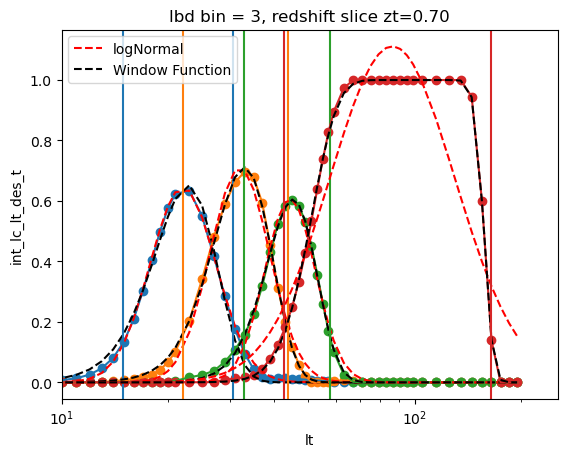

In [920]:
for i in range(4):
    plot_int_lc_lt_des_t(i, zm=0.7)

plt.xlim(10,)

In [918]:
bin_id = 1

In [833]:

intVec = np.array(intArray[bin_id]).reshape(zt.size, lt.size)
lbd_vec = np.array(lt)

pars = np.zeros((zt.size,3), dtype=float)
err = np.zeros(zt.size, dtype=float)
for i,zm in enumerate(zt):
    ix = np.argmin(np.abs(zt-zm))
    int_lbd = intVec[ix,:]
    p, rms = fit_logNormal(lbd_vec, int_lbd)
    pars[i] = p 
    err[i] = rms
    
logN = {'pars':pars, 'err':err}

In [921]:
# logN['pars']

In [835]:
# dir(fit_window)

In [932]:
keys = {"intGauss": fit_window, "logNormal": fit_logNormal}

def fitLogNormalParams(bin_id):
    intVec = np.array(intArray[bin_id]).reshape(zt.size, lt.size)
    lbd_vec = np.array(lt)
    pars = np.zeros((zt.size,3), dtype=float)
    err = np.zeros(zt.size, dtype=float)
    
    # first fit
    for i,zm in enumerate(zt):
        ix = np.argmin(np.abs(zt-zm))
        int_lbd = intVec[ix,:]
        p, rms = fit_logNormal(lbd_vec, int_lbd)
        pars[i] = p 
        err[i] = rms
    
    # learn model
    models = [np.poly1d(np.polyfit(zt, pars[:,ix], 2)) for ix in range(1,3)]
    for i,zm in enumerate(zt):
        ix = np.argmin(np.abs(zt-zm))
        int_lbd = intVec[ix,:]
        guess = [m(zm) for m in models]
        p, rms = fit_logNormal(lbd_vec, int_lbd, p0 = guess)
        pars[i] = p 
        err[i] = rms    
    return pars, err

def fitIntGaussParams(bin_id):
    intVec = np.array(intArray[bin_id]).reshape(zt.size, lt.size)
    lbd_vec = np.array(lt)
    pars = np.zeros((zt.size,3), dtype=float)
    err = np.zeros(zt.size, dtype=float)
    
    # first fit
    for i,zm in enumerate(zt):
        ix = np.argmin(np.abs(zt-zm))
        int_lbd = intVec[ix,:]
        p, rms = fit_window(lbd_vec, int_lbd)
        pars[i] = p 
        err[i] = rms
    return pars, err

def check_poly_model(bin_id, deg=2):
    intVec = np.array(intArray[bin_id]).reshape(zt.size, lt.size)
    err = np.zeros(zt.size, dtype=float)
    pars = np.zeros((zt.size,3), dtype=float)
    for i,zm in enumerate(zt):
        yt = intVec[np.argmin(np.abs(zt-zm)),:]
        p, _ = fit_window(lbd_vec, yt)
        pars[i] = p
    
    models = [get_models(pars[:,ix],deg) for ix in range(3)]
    coefs = np.zeros((3, deg+1), dtype=float)
    for j in range(3):
        coefs[j] = models[j].coef
        
    for i,zm in enumerate(zt):
        guess = [m(zm) for m in models]
        yt = intVec[np.argmin(np.abs(zt-zm)),:]
        ypre = window_function(lbd_vec, *guess)
        err[i] = compute_rms(ypre, yt)
    return coefs, err

def get_models(pars, deg=2):
    pm = np.poly1d(np.polyfit(zt, pars, deg))(zt)
    outliers = np.abs(pars-pm) > 1.0*np.nanstd(pars-pm)
    coefs = np.polyfit(zt[~outliers], pars[~outliers], deg)
    return np.poly1d(coefs)
    
def saveIntGaussModel(bin_id, err, pars):
    model_name = 'intGauss'
    np.savetxt(f"pars_{model_name}_bin_{bin_id}_err.txt", err)
    np.savetxt(f"pars_{model_name}_bin_{bin_id}_norm.txt", pars[:,0])
    np.savetxt(f"pars_{model_name}_bin_{bin_id}_norm.txt", pars[:,0])
    np.savetxt(f"pars_{model_name}_bin_{bin_id}_mean.txt", pars[:,1])
    np.savetxt(f"pars_{model_name}_bin_{bin_id}_sigma.txt", pars[:,2])
    
    # save_model()
    #wind = {'pars':pars, 'err':err}

In [966]:
bin_id = 1
pars, err = fitIntGaussParams(bin_id)
saveIntGaussModel(bin_id, err, pars)

In [967]:
coefs, errM = check_poly_model(bin_id)

(0.0, 5.0)

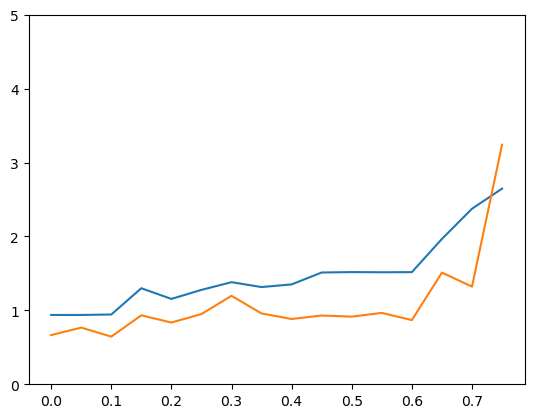

In [991]:
plt.plot(zt, 100*err)
plt.plot(zt, 100*errM)
plt.ylim(0.,5.)

In [936]:
lminV = []
lmaxV = []
sigmaV = []
for bin_id in range(4):
    coefs, errM = check_poly_model(bin_id)
    lminV.append(np.flip(coefs[0]))
    lmaxV.append(np.flip(coefs[1]))
    sigmaV.append(np.flip(coefs[2]))
    

In [944]:
np.vstack(lminV)

array([[ 18.95863528,   1.62788652,  -3.28571528],
       [ 27.27468768,   2.29035206,  -6.08255365],
       [ 39.55187894,   2.02674887,  -9.55930173],
       [ 50.27746268,   0.37022078, -10.92494646]])

In [945]:
np.vstack(lmaxV)

array([[ 26.56434598,   1.59176291,  -5.06509282],
       [ 38.5353886 ,   1.78912026,  -8.49090243],
       [ 50.94235561,   1.65517269, -12.40561457],
       [157.61882948, -21.19307273,  -8.163986  ]])

In [946]:
np.vstack(sigmaV)

array([[  3.94736142,   1.96539766,  -0.72576264],
       [  5.280042  ,   3.39603832,  -2.74077707],
       [  6.66410712,   6.35933743,  -5.62164229],
       [  7.71215638,  15.97736279, -16.15420919]])

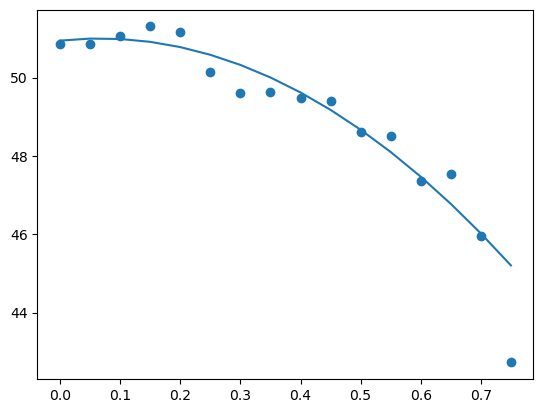

In [939]:
# plt.scatter(zt, logN['pars'][:,0])

ix = 1
# coefs = np.polyfit(zt, pars[:,ix], 2)
m = get_models(pars[:,ix])
plt.scatter(zt, pars[:,ix])
plt.plot(zt, m(zt))

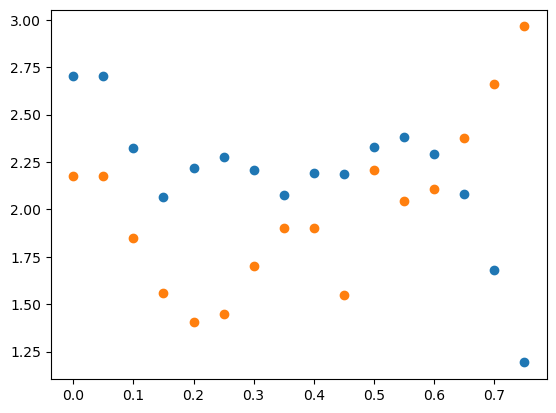

In [874]:
plt.scatter(zt, logN['err']*100)
plt.scatter(zt, err*100)

In [875]:
lbdBins = np.array([20,30,45,60,200])
lbd = 21
lbd//(lbdBins)

array([1, 0, 0, 0, 0])

In [988]:
np.mean(errM)

0.010990619110254642

In [688]:
lbdBins = np.array([20,30,45,60,200])
def get_weights(lbd):
    return lbd/lbdBins

def get_ps(zt):
    return [zt, zt**2, zt**3, zt**4, zt**5]

def main(lt, zt):
    """
    lt and zt are float numbers
    """
    weights = get_weights(lt)
    ps = get_ps(zt)
    return weights*ps

In [480]:
zm = 0.30
# lbd_vec = np.linspace(1, 80, 80)
lbd_vec = lt
int_lbd = lc_lt_integrated[np.argmin(np.abs(zt-zm)<0.01),:]
# int_lbd = lc_lt_integratedFunc(lbd_vec, zm)

In [820]:
from scipy.optimize import curve_fit
from scipy.special import erf

# Define the lognormal function
def lognormal(x, mu, sigma):
    return (1 / (x * sigma * np.sqrt(2 * np.pi))) * np.exp(- (np.log(x) - mu) ** 2 / (2 * sigma ** 2))

def lognormalAmp(x, a, mu, sigma):
    return a*lognormal(x, mu, sigma)

# Define the complementary error function
def complementary_erf(x, a, b, c):
    return a * erfc((x - b) / c)

# Define the window function
def window_function(x, xmin, xmax, sigma):
    base = np.sqrt(2) * sigma;
    return 1*(erf((xmax - x) / base) - erf((xmin - x) / base)) / 2.0

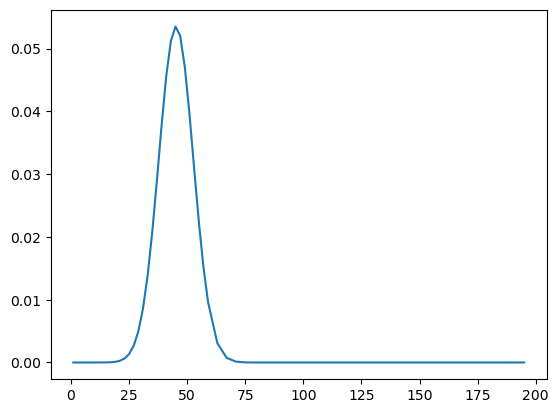

In [809]:
res = window_function(lbd_vec, 44.76433212198485, 45.66404439208907, 7.43)
norm = np.trapz(res, x=lbd_vec)
plt.plot(lbd_vec, window_function(lbd_vec, 44.76433212198485, 45.66404439208907, 7.43)/norm)

In [810]:
norm

0.9018377944152427

In [302]:
int_lbd /= np.trapz(int_lbd, x=lbd_vec)
x_data, y_data = lbd_vec, int_lbd

# Fit the data to the lognormal function
popt_lognormal, pcov_lognormal = curve_fit(lognormal, x_data, y_data, p0=[1, 1])
mu, sigma = popt_lognormal

# Fit the data to the complementary error function
popt_erf, pcov_erf = curve_fit(window_function, x_data, y_data, p0=[1, 20., 35., 5])
a, b, c, d = popt_erf

# Print the parameters
print(f"Lognormal fit parameters: mu = {mu}, sigma = {sigma}")
print(f"Complementary erf fit parameters: a = {a}, b = {b}, c = {c}")


Lognormal fit parameters: mu = 4.6261359491693055, sigma = 0.4084938635562989
Complementary erf fit parameters: a = 0.009379254501339265, b = 50.16718925646348, c = 156.87069984961795


Text(0.5, 1.0, 'lbd bin = [20, 30], redshift slice zt=0.30')

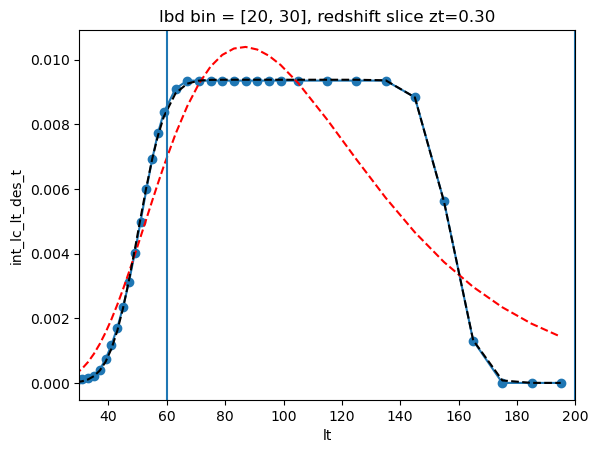

In [303]:
plt.plot(lbd_vec, int_lbd)
plt.plot(lbd_vec, lognormal(lbd_vec, *popt_lognormal), 'r--')
plt.plot(lbd_vec, window_function(lbd_vec, *popt_erf), 'k--')
plt.scatter(lbd_vec, int_lbd)
plt.axvline(60)
plt.axvline(200)
plt.xlim(30, 200)
plt.xlabel(r'lt')
plt.ylabel(r'int_lc_lt_des_t')
plt.title(r'lbd bin = [20, 30], redshift slice zt=%.2f'%zm)
# plt.xscale('log')

TypeError: complementary_erf() takes 4 positional arguments but 5 were given

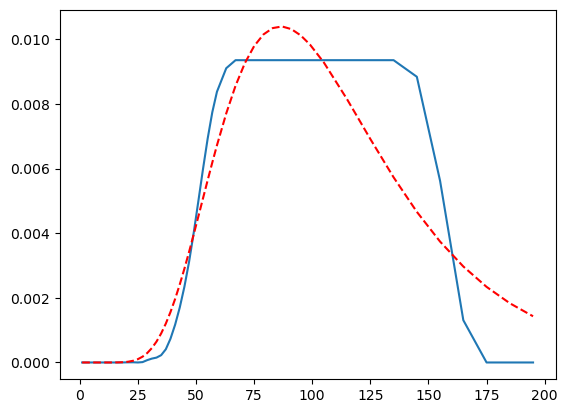

In [304]:
plt.plot(lbd_vec, int_lbd)
plt.plot(lbd_vec, lognormal(lbd_vec, *popt_lognormal), 'r--')
plt.plot(lbd_vec, complementary_erf(lbd_vec, *popt_erf), 'k--')
plt.scatter(lbd_vec, int_lbd)
plt.axvline(20)
plt.axvline(30)
plt.xlim(5, 50)
plt.xlabel(r'lt')
plt.ylabel(r'int_lc_lt_des_t')
plt.title(r'lbd bin = [20, 30], redshift slice zt=%.2f'%zm)
# plt.xscale('log')

In [197]:
# np.trapz(int_lbd, x=lbd_vec)

In [204]:
lt_bins = (1.000000, 2.000000, 3.000000, 4.000000, 5.000000, 6.000000, 7.000000, 8.000000, 9.000000, 10.000000, 11.000000, 12.000000, 13.000000, 14.000000, 15.000000, 16.000000, 17.000000, 18.000000, 19.000000, 20.000000, 21.000000, 23.000000, 25.000000, 27.000000, 29.000000, 31.000000, 33.000000, 35.000000, 37.000000, 39.000000, 41.000000, 43.000000, 45.000000, 47.000000, 49.000000, 51.000000, 53.000000, 55.000000, 57.000000, 59.000000, 63.000000, 67.000000, 71.000000, 75.000000, 79.000000, 83.000000, 87.000000, 91.000000, 95.000000, 99.000000, 105.000000, 115.000000, 125.000000, 135.000000, 145.000000, 155.000000, 165.000000, 175.000000, 185.000000, 195.000000)
zt_bins = (0.000000,0.050000,0.100000,0.150000,0.200000,0.250000,0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.600000,0.650000,0.700000,0.750000)

In [205]:
import numpy as np
path = '/global/common/software/des/jesteves/y3_cluster_cpp/data/'
np.savetxt(path+'int_lc_lt_des_t_lt_bins.txt',np.array(lt_bins))
np.savetxt(path+'int_lc_lt_des_t_zt_bins.txt',np.array(zt_bins))

In [206]:
lambda0_arr = (
    0.000000, 0.000000, 0.000000, 0.000090, 0.000000, 0.000000, 0.000000,
    0.001465, 0.003800, 0.006993, 0.013266, 0.025400, 0.046494, 0.080917,
    0.133356, 0.208246, 0.302287, 0.403247, 0.498395, 0.575000, 0.622843,
    0.634095, 0.549647, 0.416874, 0.285337, 0.175278, 0.095138, 0.043228,
    0.017411, 0.012024, 0.013102, 0.013077, 0.012081, 0.010578, 0.008983,
    0.007425, 0.005931, 0.004532, 0.003257, 0.002131, 0.000318, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000090, 0.000000, 0.000000, 0.000000, 0.001465, 0.003800, 0.006993,
    0.013266, 0.025400, 0.046494, 0.080917, 0.133356, 0.208246, 0.302287,
    0.403247, 0.498395, 0.575000, 0.622843, 0.634095, 0.549647, 0.416874,
    0.285337, 0.175278, 0.095138, 0.043228, 0.017411, 0.012024, 0.013102,
    0.013077, 0.012081, 0.010578, 0.008983, 0.007425, 0.005931, 0.004532,
    0.003257, 0.002131, 0.000318, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000056, 0.000000, 0.000000,
    0.000000, 0.000941, 0.002600, 0.005345, 0.011717, 0.024800, 0.047712,
    0.083701, 0.136045, 0.207822, 0.295955, 0.390253, 0.480131, 0.555000,
    0.606046, 0.631507, 0.556832, 0.424147, 0.289163, 0.177141, 0.097841,
    0.047282, 0.020878, 0.012158, 0.010256, 0.009153, 0.008373, 0.007682,
    0.006879, 0.005959, 0.004984, 0.004016, 0.003117, 0.002347, 0.001224,
    0.000549, 0.000190, 0.000039, 0.000000, 0.000000, 0.000000, 0.000001,
    0.000002, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000022, 0.000000, 0.000000, 0.000000, 0.000416, 0.001400,
    0.003697, 0.010167, 0.024200, 0.048931, 0.086485, 0.138734, 0.207399,
    0.289623, 0.377259, 0.461866, 0.535000, 0.589248, 0.628919, 0.564016,
    0.431420, 0.292989, 0.179004, 0.100544, 0.051335, 0.024346, 0.012292,
    0.007410, 0.005228, 0.004665, 0.004785, 0.004774, 0.004493, 0.004036,
    0.003500, 0.002978, 0.002563, 0.002130, 0.002127, 0.002424, 0.002805,
    0.003000, 0.002817, 0.002352, 0.001770, 0.001196, 0.000703, 0.000229,
    0.000000, 0.000007, 0.000005, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000005, 0.000000, 0.000000, 0.000000,
    0.000014, 0.000000, 0.000122, 0.001400, 0.005307, 0.014281, 0.031000,
    0.058038, 0.097544, 0.151565, 0.221976, 0.305558, 0.393201, 0.475464,
    0.542909, 0.587840, 0.609054, 0.546207, 0.421925, 0.277490, 0.159335,
    0.085161, 0.043610, 0.022070, 0.010422, 0.004700, 0.002645, 0.002793,
    0.003712, 0.004166, 0.003999, 0.003436, 0.002697, 0.002007, 0.001576,
    0.001492, 0.001769, 0.001660, 0.001260, 0.001209, 0.001893, 0.002741,
    0.002973, 0.002363, 0.001421, 0.000411, 0.000000, 0.000029, 0.000021,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000018, 0.000000, 0.000000, 0.000000, 0.000055, 0.000000, 0.000000,
    0.001400, 0.006154, 0.016642, 0.035400, 0.064715, 0.105862, 0.159866,
    0.227612, 0.305796, 0.386268, 0.460610, 0.520400, 0.558982, 0.575832,
    0.526147, 0.417318, 0.275093, 0.156348, 0.084119, 0.045753, 0.027053,
    0.016749, 0.010796, 0.007303, 0.005456, 0.004487, 0.003722, 0.003003,
    0.002352, 0.001790, 0.001340, 0.001021, 0.000714, 0.000626, 0.000511,
    0.000334, 0.000198, 0.000172, 0.000197, 0.000187, 0.000112, 0.000019,
    0.000000, 0.000000, 0.000017, 0.000012, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000004, 0.000000, 0.000000,
    0.000000, 0.000038, 0.000200, 0.000777, 0.002800, 0.007911, 0.019454,
    0.041200, 0.076049, 0.123422, 0.181874, 0.249886, 0.323855, 0.397764,
    0.465463, 0.520800, 0.558416, 0.572514, 0.497886, 0.372851, 0.252579,
    0.157277, 0.092633, 0.051852, 0.027596, 0.013707, 0.006931, 0.004900,
    0.005699, 0.007432, 0.008458, 0.008554, 0.007993, 0.007045, 0.005985,
    0.005070, 0.003878, 0.003191, 0.002606, 0.001990, 0.001384, 0.000832,
    0.000390, 0.000116, 0.000010, 0.000000, 0.000007, 0.000004, 0.000000,
    0.000000, 0.000001, 0.000002, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000006, 0.000000, 0.000000, 0.000000, 0.000019, 0.000000,
    0.000156, 0.001800, 0.006744, 0.017699, 0.037600, 0.068973, 0.112708,
    0.169284, 0.239045, 0.318163, 0.397990, 0.469610, 0.524105, 0.554722,
    0.554065, 0.497074, 0.396279, 0.269397, 0.161083, 0.090162, 0.048017,
    0.024842, 0.012401, 0.006361, 0.004095, 0.004100, 0.004923, 0.005305,
    0.005078, 0.004452, 0.003641, 0.002854, 0.002293, 0.001879, 0.001846,
    0.001555, 0.000960, 0.000387, 0.000089, 0.000004, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000029, 0.000000, 0.000000, 0.000000, 0.000623, 0.002400, 0.006543,
    0.016388, 0.035800, 0.067848, 0.112411, 0.168569, 0.235317, 0.308997,
    0.382884, 0.450084, 0.503701, 0.538156, 0.549611, 0.491707, 0.387148,
    0.269874, 0.170214, 0.100537, 0.055446, 0.028772, 0.014620, 0.007837,
    0.005105, 0.004838, 0.005530, 0.005866, 0.005639, 0.005022, 0.004189,
    0.003314, 0.002564, 0.001577, 0.001091, 0.000883, 0.000814, 0.000800,
    0.000778, 0.000775, 0.000832, 0.000936, 0.001001, 0.000867, 0.000267,
    0.000000, 0.000000, 0.000097, 0.000135, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000002, 0.000000, 0.000000, 0.000000, 0.000005,
    0.000000, 0.000355, 0.003000, 0.010212, 0.024117, 0.046800, 0.079906,
    0.123315, 0.176467, 0.238726, 0.307137, 0.376073, 0.439753, 0.492400,
    0.529086, 0.549353, 0.495586, 0.391295, 0.276305, 0.177487, 0.106079,
    0.058438, 0.030275, 0.016424, 0.009721, 0.005928, 0.004057, 0.003259,
    0.002785, 0.002433, 0.002191, 0.002051, 0.001999, 0.002025, 0.002167,
    0.002122, 0.001560, 0.000674, 0.000000, 0.000000, 0.000076, 0.000234,
    0.000179, 0.000034, 0.000000, 0.000000, 0.000030, 0.000021, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000001, 0.000000, 0.000022, 0.000200, 0.000934, 0.003600,
    0.010024, 0.022867, 0.045000, 0.078759, 0.124347, 0.181436, 0.249587,
    0.325060, 0.400299, 0.467535, 0.519000, 0.548563, 0.545304, 0.473373,
    0.367412, 0.262308, 0.172890, 0.105220, 0.057732, 0.028524, 0.014183,
    0.007731, 0.004727, 0.003822, 0.003801, 0.003611, 0.003087, 0.002377,
    0.001628, 0.000988, 0.000594, 0.000498, 0.000755, 0.000728, 0.000366,
    0.000000, 0.000000, 0.000000, 0.000058, 0.000210, 0.000363, 0.000574,
    0.000794, 0.000719, 0.000388, 0.000037, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000039, 0.000000,
    0.000000, 0.000000, 0.001033, 0.004801, 0.013438, 0.029206, 0.054400,
    0.090750, 0.137734, 0.194266, 0.259184, 0.328933, 0.397198, 0.457510,
    0.503400, 0.529722, 0.525595, 0.456528, 0.355518, 0.256389, 0.170420,
    0.102879, 0.054322, 0.025090, 0.012720, 0.008074, 0.005628, 0.004507,
    0.004041, 0.003639, 0.003182, 0.002714, 0.002276, 0.001913, 0.001664,
    0.001465, 0.001427, 0.001284, 0.001023, 0.000795, 0.000704, 0.000660,
    0.000534, 0.000298, 0.000050, 0.000000, 0.000000, 0.000044, 0.000031,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000028, 0.000000, 0.000000, 0.000000, 0.000110, 0.000200, 0.000812,
    0.005200, 0.016692, 0.036195, 0.064013, 0.100443, 0.145767, 0.200261,
    0.264083, 0.333777, 0.401706, 0.460003, 0.500800, 0.518381, 0.497632,
    0.434995, 0.347443, 0.245419, 0.156649, 0.093558, 0.052209, 0.027952,
    0.015782, 0.009923, 0.006910, 0.005715, 0.005418, 0.005211, 0.004893,
    0.004481, 0.003989, 0.003431, 0.002825, 0.001619, 0.000748, 0.000560,
    0.000882, 0.001204, 0.001148, 0.000827, 0.000470, 0.000205, 0.000031,
    0.000000, 0.000000, 0.000026, 0.000019, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000054,
    0.000000, 0.000000, 0.000000, 0.001124, 0.004200, 0.010859, 0.024931,
    0.050800, 0.091387, 0.143780, 0.203607, 0.266506, 0.328372, 0.385401,
    0.433806, 0.469800, 0.490392, 0.486984, 0.431273, 0.342620, 0.246502,
    0.162732, 0.100142, 0.056908, 0.030736, 0.017953, 0.011639, 0.007719,
    0.005463, 0.004289, 0.003667, 0.003372, 0.003284, 0.003283, 0.003249,
    0.003068, 0.002275, 0.001290, 0.000551, 0.000159, 0.000000, 0.000000,
    0.000000, 0.000007, 0.000010, 0.000002, 0.000000, 0.000000, 0.000002,
    0.000001, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000008, 0.000000, 0.000050, 0.000600,
    0.002443, 0.007401, 0.017713, 0.036239, 0.066000, 0.108896, 0.162360,
    0.222707, 0.286232, 0.348561, 0.404555, 0.449029, 0.476800, 0.484255,
    0.450492, 0.379651, 0.294009, 0.207352, 0.135774, 0.085312, 0.051772,
    0.030514, 0.017409, 0.009614, 0.005251, 0.003221, 0.002454, 0.002011,
    0.001653, 0.001390, 0.001231, 0.001185, 0.001259, 0.001610, 0.001836,
    0.001509, 0.000828, 0.000397, 0.000620, 0.001149, 0.001473, 0.001411,
    0.001230, 0.001255, 0.001833, 0.001897, 0.001107, 0.000149, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000023, 0.000000,
    0.000000, 0.000000, 0.000095, 0.000200, 0.001118, 0.007201, 0.023066,
    0.050837, 0.092018, 0.146811, 0.210198, 0.275862, 0.337537, 0.390554,
    0.432095, 0.459443, 0.469882, 0.461802, 0.402442, 0.311653, 0.221359,
    0.149619, 0.097243, 0.061974, 0.039450, 0.025216, 0.015684, 0.009390,
    0.005447, 0.003220, 0.002086, 0.001484, 0.001194, 0.001116, 0.001151,
    0.001199, 0.001166, 0.000848, 0.000476, 0.000366, 0.000490, 0.000601,
    0.000518, 0.000320, 0.000140, 0.000045, 0.000005, 0.000000, 0.000000,
    0.000004, 0.000003, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000)

In [207]:
np.savetxt(path+'int_lc_lt_des_t_lbd_bin0.txt',np.array(lambda0_arr).reshape(len(lt_bins),len(zt_bins)))

In [208]:
lambda1_arr = (
    0.000000, 0.000000, 0.000000, 0.000005, 0.000000, 0.000000, 0.000000,
    0.000050, 0.000000, 0.000000, 0.000000, 0.000000, 0.001210, 0.003587,
    0.006758, 0.010590, 0.016091, 0.025590, 0.041492, 0.066200, 0.101608,
    0.203457, 0.341122, 0.480704, 0.588506, 0.662430, 0.696216, 0.677593,
    0.594091, 0.453524, 0.312011, 0.200446, 0.117021, 0.058505, 0.021512,
    0.001792, 0.000000, 0.000000, 0.000743, 0.004785, 0.006568, 0.003861,
    0.001245, 0.000112, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000057, 0.000041, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000005, 0.000000, 0.000000, 0.000000, 0.000050, 0.000000, 0.000000,
    0.000000, 0.000000, 0.001210, 0.003587, 0.006758, 0.010590, 0.016091,
    0.025590, 0.041492, 0.066200, 0.101608, 0.203457, 0.341122, 0.480704,
    0.588506, 0.662430, 0.696216, 0.677593, 0.594091, 0.453524, 0.312011,
    0.200446, 0.117021, 0.058505, 0.021512, 0.001792, 0.000000, 0.000000,
    0.000743, 0.004785, 0.006568, 0.003861, 0.001245, 0.000112, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000057, 0.000041, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000002, 0.000000, 0.000000,
    0.000000, 0.000025, 0.000000, 0.000000, 0.000000, 0.000200, 0.001113,
    0.003022, 0.006364, 0.011589, 0.019610, 0.031870, 0.049842, 0.075000,
    0.108602, 0.202519, 0.332044, 0.469791, 0.580418, 0.651067, 0.674694,
    0.648761, 0.570959, 0.451102, 0.327820, 0.223451, 0.139566, 0.076835,
    0.035320, 0.011678, 0.001383, 0.000000, 0.002720, 0.005488, 0.006411,
    0.004076, 0.001900, 0.000911, 0.000596, 0.000495, 0.000445, 0.000354,
    0.000196, 0.000033, 0.000000, 0.000000, 0.000029, 0.000020, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000002,
    0.000000, 0.000000, 0.000000, 0.000007, 0.000000, 0.000000, 0.000000,
    0.000134, 0.000351, 0.000600, 0.001015, 0.002457, 0.005970, 0.012589,
    0.023130, 0.038150, 0.058192, 0.083800, 0.115597, 0.201581, 0.322966,
    0.458878, 0.572330, 0.639703, 0.653173, 0.619929, 0.547826, 0.448679,
    0.343630, 0.246456, 0.162111, 0.095166, 0.049129, 0.021565, 0.007974,
    0.003853, 0.004698, 0.006190, 0.006255, 0.004292, 0.002556, 0.001711,
    0.001395, 0.001282, 0.001235, 0.001164, 0.001027, 0.000848, 0.000559,
    0.000138, 0.000000, 0.000000, 0.000048, 0.000067, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000,
    0.000003, 0.000000, 0.000000, 0.000000, 0.000108, 0.000502, 0.001400,
    0.003076, 0.006020, 0.010775, 0.017896, 0.028236, 0.042991, 0.063380,
    0.090618, 0.125623, 0.217498, 0.334388, 0.465426, 0.584314, 0.654230,
    0.662326, 0.620360, 0.541164, 0.439401, 0.333905, 0.236870, 0.153181,
    0.087404, 0.043018, 0.017407, 0.005838, 0.003576, 0.005886, 0.008230,
    0.008397, 0.005672, 0.003734, 0.003348, 0.003397, 0.003014, 0.002361,
    0.001831, 0.001579, 0.001439, 0.001106, 0.000313, 0.000000, 0.000000,
    0.000112, 0.000157, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000006, 0.000000, 0.000000, 0.000000, 0.000065,
    0.000000, 0.000000, 0.000000, 0.000400, 0.002459, 0.006020, 0.011191,
    0.018113, 0.027854, 0.042551, 0.064400, 0.095600, 0.137346, 0.240253,
    0.345035, 0.452874, 0.560106, 0.623706, 0.627366, 0.583829, 0.507103,
    0.411870, 0.314197, 0.224427, 0.146926, 0.085802, 0.044178, 0.019675,
    0.008000, 0.004857, 0.005953, 0.007173, 0.005829, 0.002381, 0.000264,
    0.000083, 0.000613, 0.000894, 0.001033, 0.001379, 0.002015, 0.002669,
    0.003149, 0.002715, 0.001648, 0.000614, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000002,
    0.000000, 0.000000, 0.000000, 0.000022, 0.000000, 0.000000, 0.000019,
    0.000600, 0.002064, 0.005215, 0.010958, 0.020196, 0.033866, 0.052941,
    0.078394, 0.111200, 0.151922, 0.252407, 0.368175, 0.482429, 0.573762,
    0.621328, 0.618858, 0.574659, 0.497681, 0.400173, 0.302070, 0.215247,
    0.142303, 0.085431, 0.046143, 0.022111, 0.009673, 0.005166, 0.004928,
    0.005443, 0.004750, 0.003192, 0.002489, 0.002873, 0.003619, 0.004097,
    0.004092, 0.003490, 0.002405, 0.001249, 0.000159, 0.000000, 0.000080,
    0.000057, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000001, 0.000000, 0.000000, 0.000000, 0.000002, 0.000000,
    0.000000, 0.000000, 0.000077, 0.000454, 0.001400, 0.003210, 0.006287,
    0.011060, 0.017981, 0.028161, 0.043480, 0.065859, 0.097219, 0.138647,
    0.241855, 0.352365, 0.462864, 0.563583, 0.623500, 0.629453, 0.587404,
    0.504173, 0.393940, 0.288156, 0.203088, 0.137102, 0.087788, 0.052720,
    0.029393, 0.015272, 0.007823, 0.004515, 0.002903, 0.001274, 0.000964,
    0.001118, 0.001267, 0.001193, 0.000777, 0.000247, 0.000000, 0.000000,
    0.000000, 0.000081, 0.000046, 0.000000, 0.000000, 0.000018, 0.000025,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001, 0.000000,
    0.000000, 0.000000, 0.000004, 0.000000, 0.000000, 0.000000, 0.000118,
    0.000518, 0.001400, 0.003059, 0.006156, 0.011443, 0.019679, 0.031835,
    0.049126, 0.072778, 0.104021, 0.143584, 0.242131, 0.354712, 0.463917,
    0.551613, 0.602816, 0.610206, 0.573965, 0.494630, 0.383453, 0.277004,
    0.194109, 0.131899, 0.086562, 0.054460, 0.032941, 0.019689, 0.012392,
    0.008736, 0.006496, 0.003298, 0.001636, 0.001339, 0.001814, 0.002202,
    0.001890, 0.001191, 0.000627, 0.000421, 0.000400, 0.000350, 0.000109,
    0.000000, 0.000000, 0.000039, 0.000055, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000, 0.000003,
    0.000000, 0.000000, 0.000000, 0.000074, 0.000306, 0.000800, 0.001837,
    0.004407, 0.009677, 0.018804, 0.032693, 0.051958, 0.077195, 0.109000,
    0.147733, 0.243365, 0.356971, 0.465546, 0.544325, 0.584691, 0.584574,
    0.547533, 0.477383, 0.383620, 0.289140, 0.207198, 0.139314, 0.086495,
    0.049274, 0.025516, 0.012158, 0.006136, 0.004387, 0.003963, 0.003233,
    0.002592, 0.002052, 0.001597, 0.001189, 0.000811, 0.000513, 0.000362,
    0.000354, 0.000394, 0.000364, 0.000117, 0.000000, 0.000000, 0.000043,
    0.000060, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000004, 0.000000, 0.000000, 0.000000, 0.000047, 0.000000,
    0.000000, 0.000000, 0.000800, 0.003041, 0.007137, 0.013600, 0.022951,
    0.036094, 0.054371, 0.079151, 0.111800, 0.153135, 0.255771, 0.371655,
    0.474644, 0.543932, 0.576878, 0.573503, 0.535452, 0.464465, 0.369026,
    0.273594, 0.192202, 0.125965, 0.075435, 0.040722, 0.019456, 0.008404,
    0.004333, 0.004009, 0.004330, 0.003376, 0.001535, 0.000300, 0.000000,
    0.000002, 0.000035, 0.000016, 0.000000, 0.000000, 0.000000, 0.000006,
    0.000003, 0.000000, 0.000000, 0.000001, 0.000002, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000003, 0.000000,
    0.000000, 0.000000, 0.000036, 0.000000, 0.000000, 0.000095, 0.001200,
    0.003741, 0.008302, 0.015472, 0.025854, 0.040411, 0.060520, 0.087583,
    0.123000, 0.167473, 0.274502, 0.386978, 0.482249, 0.546567, 0.577150,
    0.572668, 0.532633, 0.456624, 0.353666, 0.255138, 0.177391, 0.118264,
    0.074793, 0.044095, 0.023765, 0.011558, 0.005232, 0.002545, 0.001336,
    0.000236, 0.000148, 0.000285, 0.000358, 0.000401, 0.000438, 0.000438,
    0.000356, 0.000198, 0.000034, 0.000000, 0.000000, 0.000029, 0.000021,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000004, 0.000000, 0.000000, 0.000000, 0.000045,
    0.000000, 0.000000, 0.000092, 0.001400, 0.004439, 0.009947, 0.018678,
    0.031392, 0.048960, 0.072379, 0.102657, 0.140800, 0.187092, 0.293012,
    0.395200, 0.481653, 0.545367, 0.569833, 0.550802, 0.496875, 0.417219,
    0.324092, 0.236856, 0.165455, 0.109278, 0.067255, 0.038148, 0.019781,
    0.009655, 0.005265, 0.004112, 0.003792, 0.002713, 0.001515, 0.000791,
    0.000588, 0.000600, 0.000576, 0.000483, 0.000340, 0.000174, 0.000028,
    0.000000, 0.000000, 0.000025, 0.000018, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000002,
    0.000000, 0.000000, 0.000000, 0.000022, 0.000000, 0.000000, 0.000138,
    0.001000, 0.003035, 0.007250, 0.014776, 0.026738, 0.044051, 0.067391,
    0.097420, 0.134800, 0.179656, 0.283180, 0.388018, 0.472647, 0.524628,
    0.543574, 0.530680, 0.488056, 0.417865, 0.328444, 0.242692, 0.172743,
    0.117690, 0.076061, 0.046307, 0.026459, 0.014402, 0.008018, 0.005194,
    0.003886, 0.002739, 0.002492, 0.002020, 0.001209, 0.000590, 0.000529,
    0.000734, 0.000768, 0.000476, 0.000084, 0.000000, 0.000000, 0.000073,
    0.000052, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000,
    0.000008, 0.000000, 0.000037, 0.000535, 0.002000, 0.005075, 0.010953,
    0.020966, 0.036434, 0.058316, 0.087157, 0.123478, 0.167800, 0.219926,
    0.334592, 0.438206, 0.508377, 0.539125, 0.535295, 0.501774, 0.442905,
    0.363022, 0.271840, 0.191650, 0.132568, 0.090554, 0.060949, 0.039506,
    0.024273, 0.014093, 0.007814, 0.004281, 0.002372, 0.001228, 0.001803,
    0.002052, 0.001521, 0.000782, 0.000300, 0.000068, 0.000000, 0.000000,
    0.000000, 0.000142, 0.000496, 0.000598, 0.000365, 0.000049, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000012, 0.000000, 0.000000, 0.000000, 0.000152, 0.000200, 0.000090,
    0.000714, 0.003201, 0.008754, 0.018873, 0.035134, 0.059073, 0.091135,
    0.130495, 0.176260, 0.227537, 0.282994, 0.393732, 0.481227, 0.526511,
    0.525991, 0.484638, 0.413462, 0.329069, 0.248291, 0.182664, 0.130776,
    0.090199, 0.059440, 0.037049, 0.021589, 0.011729, 0.006169, 0.003610,
    0.002753, 0.002351, 0.001408, 0.000581, 0.000231, 0.000288, 0.000401,
    0.000309, 0.000106, 0.000000, 0.000000, 0.000000, 0.000035, 0.000020,
    0.000000, 0.000000, 0.000008, 0.000011, 0.000000, 0.000000, 0.000000,
    0.000000)


In [209]:
np.savetxt(path+'int_lc_lt_des_t_lbd_bin1.txt',np.array(lambda1_arr).reshape(len(lt_bins),len(zt_bins)))

In [210]:
lambda2_arr = (
    0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000,
    0.000008, 0.000000, 0.000000, 0.000000, 0.000000, 0.000148, 0.000265,
    0.000118, 0.000000, 0.000000, 0.000000, 0.000000, 0.000400, 0.004824,
    0.016421, 0.024494, 0.037917, 0.067747, 0.107650, 0.157619, 0.225006,
    0.317442, 0.429533, 0.524837, 0.582537, 0.602247, 0.584468, 0.531018,
    0.451083, 0.356413, 0.258759, 0.169872, 0.100884, 0.024982, 0.001988,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000399, 0.000384,
    0.000264, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000001, 0.000000, 0.000000, 0.000000, 0.000008, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000148, 0.000265, 0.000118, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000400, 0.004824, 0.016421, 0.024494, 0.037917,
    0.067747, 0.107650, 0.157619, 0.225006, 0.317442, 0.429533, 0.524837,
    0.582537, 0.602247, 0.584468, 0.531018, 0.451083, 0.356413, 0.258759,
    0.169872, 0.100884, 0.024982, 0.001988, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000399, 0.000384, 0.000264, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000004, 0.000000, 0.000000, 0.000000, 0.000000, 0.000074,
    0.000132, 0.000094, 0.000000, 0.000000, 0.000000, 0.000135, 0.001600,
    0.004233, 0.012830, 0.025386, 0.044951, 0.075431, 0.117559, 0.172217,
    0.240617, 0.323966, 0.416521, 0.495978, 0.548432, 0.570933, 0.561011,
    0.517720, 0.448654, 0.364371, 0.275438, 0.192417, 0.125348, 0.043469,
    0.009935, 0.000000, 0.000000, 0.001455, 0.002188, 0.001414, 0.000519,
    0.000192, 0.000187, 0.000212, 0.000075, 0.000000, 0.000000, 0.000028,
    0.000039, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000,
    0.000009, 0.000015, 0.000000, 0.000000, 0.000000, 0.000070, 0.000350,
    0.000817, 0.001419, 0.002099, 0.002800, 0.003643, 0.009238, 0.026278,
    0.051986, 0.083114, 0.127468, 0.186815, 0.256229, 0.330490, 0.403509,
    0.467119, 0.514326, 0.539619, 0.537555, 0.504423, 0.446224, 0.372330,
    0.292117, 0.214962, 0.149811, 0.061957, 0.017883, 0.002083, 0.001764,
    0.005876, 0.005986, 0.003167, 0.000639, 0.000000, 0.000110, 0.000435,
    0.000201, 0.000000, 0.000000, 0.000076, 0.000107, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000002, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000046, 0.000110, 0.000173, 0.000219, 0.000329, 0.000697, 0.001521,
    0.003001, 0.005362, 0.014100, 0.030520, 0.055537, 0.089652, 0.134967,
    0.191615, 0.257655, 0.331050, 0.406528, 0.471122, 0.515877, 0.537041,
    0.531088, 0.495939, 0.437598, 0.364881, 0.286607, 0.211594, 0.148254,
    0.062486, 0.018831, 0.002278, 0.000751, 0.004067, 0.004380, 0.002320,
    0.000437, 0.000000, 0.000124, 0.000394, 0.000178, 0.000000, 0.000000,
    0.000067, 0.000094, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000006, 0.000009, 0.000000, 0.000000, 0.000000, 0.000091,
    0.000325, 0.000792, 0.001631, 0.002986, 0.005000, 0.007845, 0.017225,
    0.033768, 0.062461, 0.105565, 0.159461, 0.221021, 0.287952, 0.357985,
    0.425749, 0.478554, 0.508918, 0.515717, 0.498101, 0.456228, 0.395881,
    0.324801, 0.250730, 0.181410, 0.124205, 0.049895, 0.014683, 0.001538,
    0.000000, 0.001653, 0.002492, 0.002168, 0.002067, 0.002795, 0.003917,
    0.005396, 0.006611, 0.006181, 0.004554, 0.002721, 0.001694, 0.001350,
    0.000451, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000006, 0.000009,
    0.000000, 0.000000, 0.000025, 0.000208, 0.000611, 0.001269, 0.002167,
    0.003284, 0.004600, 0.006295, 0.014922, 0.037883, 0.073505, 0.116063,
    0.167093, 0.226206, 0.290661, 0.357602, 0.421162, 0.468392, 0.492361,
    0.493256, 0.471580, 0.428587, 0.369763, 0.302063, 0.232443, 0.167859,
    0.114924, 0.046913, 0.015368, 0.003730, 0.001791, 0.003441, 0.003932,
    0.003282, 0.002591, 0.002380, 0.002396, 0.002287, 0.001616, 0.000816,
    0.000208, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000002, 0.000000, 0.000000, 0.000000, 0.000000, 0.000048, 0.000113,
    0.000174, 0.000217, 0.000361, 0.000882, 0.002067, 0.004201, 0.007583,
    0.019518, 0.040675, 0.071163, 0.110312, 0.159541, 0.218174, 0.283312,
    0.351948, 0.417703, 0.466284, 0.490341, 0.490710, 0.468581, 0.425792,
    0.367774, 0.301214, 0.232799, 0.169214, 0.116816, 0.048479, 0.015518,
    0.002287, 0.000000, 0.000031, 0.000512, 0.000236, 0.000000, 0.000000,
    0.000000, 0.000082, 0.000047, 0.000000, 0.000000, 0.000018, 0.000025,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000001, 0.000000, 0.000000, 0.000000, 0.000010, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000200, 0.000384, 0.000366, 0.000000, 0.000000,
    0.000000, 0.000164, 0.002801, 0.007577, 0.021620, 0.038048, 0.067546,
    0.116539, 0.169432, 0.220667, 0.276015, 0.341713, 0.414406, 0.467966,
    0.489765, 0.484205, 0.456433, 0.411622, 0.355101, 0.292254, 0.228466,
    0.169121, 0.119343, 0.051307, 0.015809, 0.001447, 0.000000, 0.001252,
    0.001867, 0.001022, 0.000129, 0.000000, 0.000000, 0.000105, 0.000059,
    0.000000, 0.000000, 0.000023, 0.000032, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000005, 0.000007, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000037, 0.000275, 0.000921, 0.002216, 0.004400,
    0.007741, 0.019436, 0.040508, 0.073907, 0.119436, 0.173483, 0.232509,
    0.293240, 0.352413, 0.405594, 0.445622, 0.467914, 0.470895, 0.453119,
    0.414118, 0.358885, 0.294311, 0.227288, 0.164710, 0.113132, 0.046178,
    0.014367, 0.002161, 0.000000, 0.001032, 0.001255, 0.000475, 0.000000,
    0.000000, 0.000128, 0.000380, 0.000170, 0.000000, 0.000000, 0.000064,
    0.000090, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000003, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000072, 0.000156, 0.000205, 0.000177,
    0.000171, 0.000456, 0.001307, 0.003000, 0.005901, 0.018292, 0.044507,
    0.082702, 0.128299, 0.182473, 0.243589, 0.306858, 0.367348, 0.418733,
    0.451537, 0.461827, 0.451724, 0.423615, 0.380210, 0.326033, 0.266239,
    0.205986, 0.150429, 0.104466, 0.043440, 0.013106, 0.000990, 0.000000,
    0.000039, 0.000649, 0.000299, 0.000000, 0.000000, 0.000000, 0.000105,
    0.000059, 0.000000, 0.000000, 0.000023, 0.000032, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000005, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000105, 0.000215, 0.000247, 0.000124, 0.000000, 0.000249, 0.001313,
    0.003600, 0.007520, 0.021833, 0.047318, 0.085574, 0.135024, 0.191977,
    0.252673, 0.313398, 0.370434, 0.418574, 0.449197, 0.458561, 0.448354,
    0.420501, 0.377313, 0.323283, 0.263658, 0.203686, 0.148616, 0.103429,
    0.044486, 0.015854, 0.003864, 0.000289, 0.000412, 0.000495, 0.000191,
    0.000000, 0.000000, 0.000000, 0.000065, 0.000037, 0.000000, 0.000000,
    0.000014, 0.000020, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000005,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000101, 0.000208, 0.000242,
    0.000132, 0.000078, 0.000587, 0.002185, 0.005400, 0.010686, 0.028085,
    0.055255, 0.092878, 0.141462, 0.201251, 0.268160, 0.333780, 0.389518,
    0.428078, 0.445493, 0.441682, 0.419971, 0.383831, 0.336822, 0.282986,
    0.226532, 0.171670, 0.122608, 0.083326, 0.034333, 0.012568, 0.003792,
    0.000644, 0.000199, 0.000129, 0.000041, 0.000000, 0.000000, 0.000000,
    0.000013, 0.000008, 0.000000, 0.000000, 0.000003, 0.000004, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000,
    0.000000, 0.000003, 0.000000, 0.000000, 0.000000, 0.000059, 0.000139,
    0.000200, 0.000231, 0.000342, 0.000672, 0.001358, 0.002539, 0.004349,
    0.006924, 0.010400, 0.015002, 0.030031, 0.057228, 0.098905, 0.152800,
    0.214577, 0.278391, 0.336985, 0.383055, 0.412049, 0.426099, 0.426649,
    0.413436, 0.386120, 0.344992, 0.293847, 0.237700, 0.181566, 0.130460,
    0.089138, 0.037062, 0.013497, 0.004097, 0.001103, 0.001006, 0.001024,
    0.000789, 0.000484, 0.000225, 0.000035, 0.000000, 0.000000, 0.000030,
    0.000022, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001, 0.000000,
    0.000000, 0.000000, 0.000021, 0.000033, 0.000000, 0.000000, 0.000000,
    0.000127, 0.000719, 0.001822, 0.003558, 0.006044, 0.009400, 0.013949,
    0.031410, 0.068317, 0.119172, 0.174360, 0.236999, 0.304006, 0.365322,
    0.410600, 0.432589, 0.431716, 0.411380, 0.376803, 0.333288, 0.285773,
    0.237163, 0.189652, 0.145435, 0.106707, 0.075529, 0.035029, 0.015081,
    0.005677, 0.001483, 0.000183, 0.000000, 0.000000, 0.000033, 0.000047,
    0.000010, 0.000000, 0.000000, 0.000009, 0.000006, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001,
    0.000002, 0.000000, 0.000016, 0.000167, 0.000593, 0.001438, 0.002969,
    0.005596, 0.009737, 0.015809, 0.024378, 0.053772, 0.107250, 0.173398,
    0.238172, 0.307873, 0.377316, 0.428615, 0.443367, 0.416167, 0.372814,
    0.328982, 0.285429, 0.242263, 0.199735, 0.158896, 0.121073, 0.087597,
    0.059794, 0.038890, 0.015608, 0.007739, 0.004618, 0.002168, 0.000569,
    0.000000, 0.000000, 0.000036, 0.000052, 0.000011, 0.000000, 0.000000,
    0.000010, 0.000007, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000)

In [211]:
np.savetxt(path+'int_lc_lt_des_t_lbd_bin2.txt',np.array(lambda2_arr).reshape(len(lt_bins),len(zt_bins)))

In [212]:
lambda3_arr = (
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000001, 0.000002, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000010, 0.000048, 0.000119, 0.000233, 0.000400, 0.000535,
    0.000647, 0.000000, 0.001232, 0.007765, 0.012791, 0.016135, 0.024214,
    0.043723, 0.078418, 0.124971, 0.181899, 0.250644, 0.332779, 0.428844,
    0.533614, 0.639857, 0.740343, 0.827838, 0.895538, 0.973436, 1.000000,
    1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
    1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 0.945102, 0.600790,
    0.139850, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001,
    0.000002, 0.000000, 0.000000, 0.000000, 0.000000, 0.000010, 0.000048,
    0.000119, 0.000233, 0.000400, 0.000535, 0.000647, 0.000000, 0.001232,
    0.007765, 0.012791, 0.016135, 0.024214, 0.043723, 0.078418, 0.124971,
    0.181899, 0.250644, 0.332779, 0.428844, 0.533614, 0.639857, 0.740343,
    0.827838, 0.895538, 0.973436, 1.000000, 1.000000, 1.000000, 1.000000,
    1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
    1.000000, 1.000000, 0.945102, 0.600790, 0.139850, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000002, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000009, 0.000040, 0.000083, 0.000137, 0.000200,
    0.000267, 0.000378, 0.000501, 0.003181, 0.009371, 0.015435, 0.022132,
    0.034885, 0.059314, 0.097996, 0.146208, 0.201883, 0.266726, 0.342606,
    0.430463, 0.526036, 0.623253, 0.716044, 0.798338, 0.864400, 0.947926,
    0.985290, 0.998371, 1.000000, 0.997948, 0.997329, 0.998179, 0.999067,
    0.999393, 0.999670, 1.000000, 1.000000, 0.988643, 0.938831, 0.812169,
    0.568757, 0.266600, 0.018200, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000001, 0.000002, 0.000000, 0.000000, 0.000000, 0.000000, 0.000008,
    0.000031, 0.000047, 0.000042, 0.000000, 0.000000, 0.000109, 0.001519,
    0.005130, 0.010978, 0.018079, 0.028128, 0.045556, 0.074906, 0.117573,
    0.167445, 0.221868, 0.282808, 0.352434, 0.432083, 0.518457, 0.606649,
    0.691746, 0.768838, 0.833263, 0.922417, 0.969425, 0.987369, 0.988632,
    0.985145, 0.985992, 0.989813, 0.992891, 0.993384, 0.991958, 0.987350,
    0.964678, 0.905764, 0.806551, 0.679236, 0.536723, 0.393350, 0.252450,
    0.111550, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000006, 0.000011, 0.000008, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000126, 0.000934, 0.003102, 0.007462, 0.014417, 0.023807,
    0.036880, 0.056331, 0.084912, 0.124104, 0.172325, 0.228563, 0.292847,
    0.365251, 0.445353, 0.529965, 0.614937, 0.696118, 0.769356, 0.830715,
    0.916617, 0.963174, 0.982214, 0.985160, 0.983177, 0.984752, 0.988541,
    0.990974, 0.990059, 0.985911, 0.973779, 0.930808, 0.845818, 0.714074,
    0.541851, 0.335907, 0.119850, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000024, 0.000042, 0.000030,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000200, 0.000781, 0.002635,
    0.005129, 0.009599, 0.017094, 0.026487, 0.038869, 0.057672, 0.086433,
    0.127738, 0.181805, 0.247376, 0.322068, 0.403450, 0.488977, 0.575465,
    0.659507, 0.737697, 0.806627, 0.863090, 0.939261, 0.978327, 0.994407,
    0.997849, 0.996571, 0.996520, 0.996543, 0.993899, 0.987672, 0.979392,
    0.965733, 0.929853, 0.855351, 0.734229, 0.576287, 0.392095, 0.202023,
    0.019153, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000020, 0.000037, 0.000026, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000349, 0.001253, 0.001938, 0.006171, 0.016449,
    0.028894, 0.043821, 0.066118, 0.100865, 0.150329, 0.209987, 0.276582,
    0.349165, 0.426884, 0.508590, 0.591457, 0.672078, 0.747045, 0.812950,
    0.866585, 0.937723, 0.972676, 0.985652, 0.986905, 0.984137, 0.983184,
    0.983175, 0.981735, 0.978100, 0.973657, 0.967434, 0.940573, 0.856885,
    0.708191, 0.520171, 0.319977, 0.125400, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000001, 0.000000, 0.000000, 0.000000, 0.000000, 0.000027, 0.000048,
    0.000034, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000462,
    0.001849, 0.003400, 0.007284, 0.014865, 0.023620, 0.035827, 0.058799,
    0.100050, 0.160666, 0.226405, 0.290498, 0.356024, 0.426488, 0.504443,
    0.587117, 0.669883, 0.748113, 0.817179, 0.872719, 0.943838, 0.977207,
    0.990997, 0.995429, 0.995591, 0.995346, 0.994346, 0.991300, 0.985873,
    0.979016, 0.967361, 0.932180, 0.852612, 0.724766, 0.569534, 0.408888,
    0.254450, 0.096550, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000001, 0.000002, 0.000001, 0.000000, 0.000000,
    0.000023, 0.000084, 0.000200, 0.000392, 0.001153, 0.002745, 0.007031,
    0.015693, 0.028575, 0.047141, 0.074586, 0.114175, 0.166760, 0.227400,
    0.293006, 0.363232, 0.437848, 0.516282, 0.596036, 0.673941, 0.746829,
    0.811530, 0.865053, 0.938565, 0.976975, 0.991840, 0.993293, 0.990549,
    0.990511, 0.991636, 0.990478, 0.985435, 0.977368, 0.961165, 0.916806,
    0.836423, 0.714948, 0.558878, 0.375213, 0.183825, 0.001035, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000001, 0.000001, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000004, 0.000021, 0.000055, 0.000113, 0.000200,
    0.000352, 0.001475, 0.004821, 0.010667, 0.019089, 0.031243, 0.049735,
    0.078560, 0.121762, 0.179521, 0.242798, 0.307153, 0.374170, 0.445694,
    0.522892, 0.603127, 0.682441, 0.756875, 0.822468, 0.875491, 0.944455,
    0.977515, 0.990588, 0.993590, 0.992570, 0.992135, 0.991823, 0.990017,
    0.985472, 0.977438, 0.957376, 0.898698, 0.803017, 0.669742, 0.504020,
    0.311246, 0.110350, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000002, 0.000003, 0.000000, 0.000000, 0.000000, 0.000000, 0.000013,
    0.000053, 0.000104, 0.000156, 0.000200, 0.000250, 0.000819, 0.002963,
    0.009481, 0.021227, 0.035007, 0.052229, 0.079139, 0.122181, 0.183470,
    0.254686, 0.330096, 0.408146, 0.487467, 0.566594, 0.643544, 0.716151,
    0.782250, 0.839676, 0.886404, 0.949264, 0.981517, 0.995171, 0.998319,
    0.996533, 0.994308, 0.992345, 0.990458, 0.987945, 0.983416, 0.969845,
    0.920437, 0.825136, 0.687864, 0.530897, 0.377313, 0.233650, 0.082950,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000026, 0.000046, 0.000033, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000200, 0.000812, 0.002611, 0.004695, 0.010358, 0.021886, 0.036074,
    0.054387, 0.083278, 0.129404, 0.194174, 0.266420, 0.339600, 0.413736,
    0.489132, 0.565752, 0.641648, 0.714206, 0.780811, 0.838849, 0.885868,
    0.948118, 0.978980, 0.991415, 0.994059, 0.992762, 0.992013, 0.991464,
    0.989666, 0.985731, 0.979519, 0.965339, 0.919318, 0.828528, 0.698474,
    0.559701, 0.443847, 0.348450, 0.236550, 0.124650, 0.012750, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000001,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000015, 0.000026, 0.000019,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000200, 0.000647, 0.002632,
    0.006832, 0.013981, 0.024616, 0.039351, 0.061203, 0.095597, 0.148047,
    0.219139, 0.297653, 0.376673, 0.455406, 0.533324, 0.609729, 0.682972,
    0.751072, 0.812046, 0.863914, 0.904840, 0.956380, 0.979614, 0.988635,
    0.991069, 0.990368, 0.989095, 0.986798, 0.982355, 0.975543, 0.967342,
    0.954038, 0.922240, 0.862856, 0.766901, 0.634424, 0.465869, 0.283950,
    0.115450, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000008, 0.000013,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000057, 0.000227, 0.000392,
    0.000475, 0.000400, 0.000181, 0.000913, 0.006165, 0.015838, 0.027982,
    0.042826, 0.064013, 0.098481, 0.153289, 0.228545, 0.307765, 0.382359,
    0.454195, 0.525593, 0.598274, 0.670601, 0.739766, 0.802963, 0.857385,
    0.900408, 0.954297, 0.978765, 0.989422, 0.993879, 0.994590, 0.993407,
    0.990278, 0.984720, 0.976383, 0.965099, 0.942308, 0.887327, 0.809161,
    0.711756, 0.605281, 0.500176, 0.399500, 0.295700, 0.191900, 0.088100,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000001, 0.000000, 0.000000, 0.000000, 0.000000, 0.000029, 0.000052,
    0.000036, 0.000000, 0.000000, 0.000000, 0.000000, 0.000200, 0.000878,
    0.003202, 0.006896, 0.017103, 0.035969, 0.056573, 0.080288, 0.117322,
    0.178241, 0.264583, 0.356275, 0.441739, 0.521221, 0.595480, 0.665067,
    0.729370, 0.787372, 0.838055, 0.880402, 0.913491, 0.954733, 0.972701,
    0.978939, 0.979188, 0.975445, 0.968964, 0.958502, 0.942283, 0.920305,
    0.894947, 0.854825, 0.775179, 0.660453, 0.510595, 0.347733, 0.194959,
    0.054626, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
    0.000000, 0.000000, 0.000001, 0.000002, 0.000002, 0.000000, 0.000048,
    0.000255, 0.000735, 0.001601, 0.002934, 0.006806, 0.012138, 0.026082,
    0.053782, 0.089750, 0.134230, 0.193826, 0.275394, 0.377552, 0.479267,
    0.568901, 0.647249, 0.715646, 0.775298, 0.826700, 0.870095, 0.905728,
    0.933844, 0.954726, 0.978658, 0.987442, 0.990928, 0.992667, 0.992150,
    0.988492, 0.979684, 0.963475, 0.938350, 0.903775, 0.833817, 0.678901,
    0.496403, 0.312320, 0.155206, 0.053726, 0.000000, 0.000000, 0.000000,
    0.000000)

In [213]:
np.savetxt(path+'int_lc_lt_des_t_lbd_bin3.txt',np.array(lambda3_arr).reshape(len(lt_bins),len(zt_bins)))

In [214]:
len(lt_bins),len(zt_bins)

(60, 16)

In [49]:
len(lambda0_arr)

960

In [50]:
len(lambda1_arr)

960

In [51]:
len(lambda2_arr)

960

In [52]:
len(lambda3_arr)

960

In [976]:
import numpy as np

def print_array(label,arr):
    l1 = "%s = {"%label
    print(l1)
    for row in arr:
        print(len(l1)*" "+"{", end="")
        for i in range(len(row)):
            print("{:.8f}".format(row[i]), end="")
            if i < len(row) - 1:
                print(", ", end="")
        print("},")
    print("}")

# Example array
a = np.array([[18.95863528, 1.62788652, -3.28571528],
              [27.27468768, 2.29035206, -6.08255365],
              [39.55187894, 2.02674887, -9.55930173],
              [50.27746268, 0.37022078, -10.92494646]])

# Print array with C++-like syntax
print_array("a",a)


a = {
     {18.95863528, 1.62788652, -3.28571528},
     {27.27468768, 2.29035206, -6.08255365},
     {39.55187894, 2.02674887, -9.55930173},
     {50.27746268, 0.37022078, -10.92494646},
}


In [986]:
def print_pars(label,arr):
    l1 = "std::vector<std::vector<double>> %s = {"%label
    print(l1)
    sp = len(l1)*" "
    for row in arr:
        print(sp+"{", end="")
        for i in range(len(row)):
            print("{:.8f}".format(row[i]), end="")
            if i < len(row) - 1:
                print(", ", end="")
        print("},")
    print(sp+"}")

In [985]:
print_pars("lminV",lminV)

std::vector<std::vector<double>> lminV = {
                                          {18.95863528, 1.62788652, -3.28571528},
                                          {27.27468768, 2.29035206, -6.08255365},
                                          {39.55187894, 2.02674887, -9.55930173},
                                          {50.27746268, 0.37022078, -10.92494646},
                                          }


In [987]:
print_pars("lmax",lmaxV)
print_pars("sigma",sigmaV)


std::vector<std::vector<double>> lmax = {
                                         {26.56434598, 1.59176291, -5.06509282},
                                         {38.53538860, 1.78912026, -8.49090243},
                                         {50.94235561, 1.65517269, -12.40561457},
                                         {157.61882948, -21.19307273, -8.16398600},
                                         }
std::vector<std::vector<double>> sigma = {
                                          {3.94736142, 1.96539766, -0.72576264},
                                          {5.28004200, 3.39603832, -2.74077707},
                                          {6.66410712, 6.35933743, -5.62164229},
                                          {7.71215638, 15.97736279, -16.15420919},
                                          }
